# Phase 3: Cleaning, Alignment & Master DataFrame

**Goal:** Transform three raw, misaligned datasets into a single `master_df.csv` that every downstream phase reads from.

**Inputs:**
- `data/raw/vix_raw.csv` - daily VIX close (Phase 1)
- `data/raw/macro_raw.csv` - from 6 FRED monthly series (Phase 2)
- `data/raw/news_raw.csv` - 870K deduplicated financial headlines (Phase 2)

**Outputs:**
- `data/processed/sentiment_scores.csv` - FinBERT daily sentiment (run once, reuse always)
- `data/processed/master_df.csv` - single aligned dataset for all models
- `models/scaler.pkl` - fitted StandardScaler (train set only)
- `models/scaler_features.json` - exact list of scaled columns

In [4]:
import os, sys
os.makedirs('../logs', exist_ok=True)
open('../logs/cleaning_log.txt', 'a').close()

sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.cleaning import (
    clean_vix, clean_macro, build_sentiment,
    build_master, fit_and_apply_scaler,
    run_quality_checks, TRAIN_END, VAL_END,
    MASTER_PATH, SENTIMENT_PATH
)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('Setup complete.')

Setup complete.


## 1. Clean VIX

Strips weekends, deduplicates the date index, and engineers all VIX-derived features:
- **Lag features** (`vix_lag1/5/21`): capture short, medium, and long-term momentum ; directly motivated by Phase 1 ACF findings
- **Rolling features** (`vix_roll_mean5`, `vix_roll_std21`): smooth signal and capture local volatility regime
- **`vix_log`**: log-transformed target; candidate for LSTM training (Phase 1 showed right skew ~2.0)
- **`vix_return`**: daily % change; direct input to GARCH in Phase 4
- **`regime_label`**: LOW / ELEVATED / CRISIS at thresholds 20 / 30; validated against Phase 1 percentile analysis

In [6]:
vix_df = clean_vix()
print(f'Shape: {vix_df.shape}')
vix_df.head()

2026-04-06 21:52:35,535 [INFO] VIX cleaned: 6598 rows, 2000-01-03 to 2026-03-27


Shape: (6598, 9)


,vix,vix_log,vix_return,vix_lag1,vix_lag5,vix_lag21,vix_roll_mean5,vix_roll_std21,regime_label
date,,,,,,,,,
2000-01-03,24.209999,3.186766,NaN,NaN,NaN,NaN,NaN,NaN,ELEVATED
2000-01-04,27.010000,3.296207,0.115655,24.209999,NaN,NaN,NaN,NaN,ELEVATED
2000-01-05,26.410000,3.273743,-0.022214,27.010000,NaN,NaN,NaN,NaN,ELEVATED
2000-01-06,25.730000,3.247658,-0.025748,26.410000,NaN,NaN,NaN,NaN,ELEVATED
2000-01-07,21.719999,3.078233,-0.155849,25.730000,NaN,NaN,25.016,NaN,ELEVATED


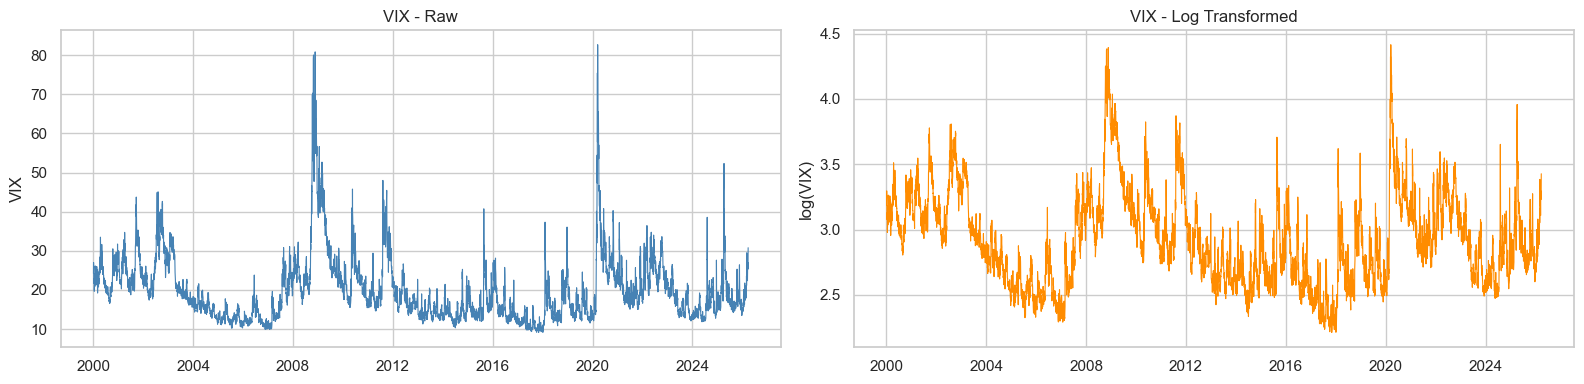

Saved: figures/vix_raw_vs_log.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(vix_df.index, vix_df['vix'], color='steelblue', linewidth=0.8)
axes[0].set_title('VIX - Raw')
axes[0].set_ylabel('VIX')

axes[1].plot(vix_df.index, vix_df['vix_log'], color='darkorange', linewidth=0.8)
axes[1].set_title('VIX - Log Transformed')
axes[1].set_ylabel('log(VIX)')

plt.tight_layout()
plt.savefig('figures/vix_raw_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/vix_raw_vs_log.png')

## 2. Clean Macro

FRED series are monthly. Forward-filling to business-day frequency (`resample('B').ffill()`) carries the last known value forward until the next monthly release; the standard approach for lagged macro indicators. The 1–2 month reporting lag is by design: FRED publishes with a delay.

In [9]:
macro_df = clean_macro()
print(f'Shape: {macro_df.shape}')
macro_df.tail()

2026-04-06 21:57:36,367 [INFO] Macro forward-filled to 6806 business-day rows


Shape: (6806, 6)


,fedfunds,cpi,unrate,gs10,indpro,m2sl
date,,,,,,
2026-01-26,3.64,326.588,4.3,4.21,102.3963,22469.1
2026-01-27,3.64,326.588,4.3,4.21,102.3963,22469.1
2026-01-28,3.64,326.588,4.3,4.21,102.3963,22469.1
2026-01-29,3.64,326.588,4.3,4.21,102.3963,22469.1
2026-01-30,3.64,326.588,4.3,4.21,102.3963,22469.1


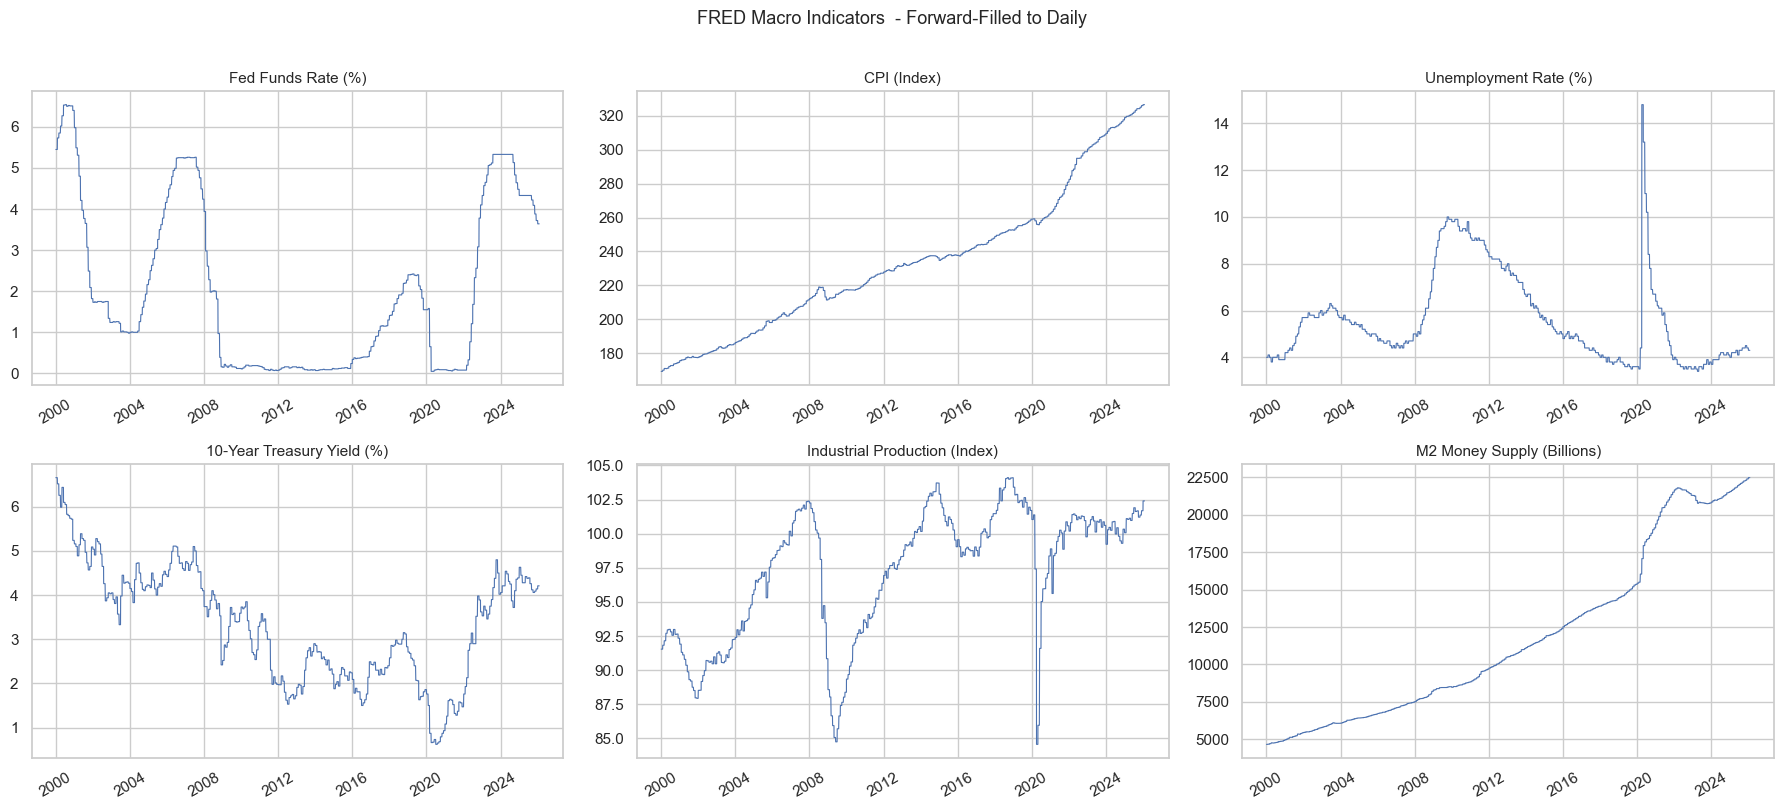

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

labels = {
    'fedfunds': 'Fed Funds Rate (%)',
    'cpi':      'CPI (Index)',
    'unrate':   'Unemployment Rate (%)',
    'gs10':     '10-Year Treasury Yield (%)',
    'indpro':   'Industrial Production (Index)',
    'm2sl':     'M2 Money Supply (Billions)',
}

for ax, (col, label) in zip(axes, labels.items()):
    ax.plot(macro_df.index, macro_df[col], linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('FRED Macro Indicators  - Forward-Filled to Daily', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/macro_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. FinBERT Sentiment Inference

FinBERT (`ProsusAI/finbert`) is a BERT model fine-tuned on financial text. It outperforms general-purpose sentiment tools (VADER, TextBlob) on financial language because it was trained on earnings calls and analyst reports not movie reviews.

**Compound score** = `P(positive) − P(negative)` → range [−1, +1]  
**Daily score** = mean of all headlines on that date  
**Missing days** = 0.0 (neutral), flagged as `sentiment_source = 'default_neutral'`


In [24]:
# Load Kaggle
kaggle = pd.read_csv('data/raw/analyst_ratings_processed.csv')
kaggle = kaggle.rename(columns={'title': 'headline'})
kaggle = kaggle[['date', 'headline']]
kaggle['source'] = 'kaggle'
kaggle['date'] = pd.to_datetime(kaggle['date'], utc=True, errors='coerce')
kaggle['date'] = kaggle['date'].dt.tz_localize(None).dt.normalize()
kaggle = kaggle.dropna(subset=['date', 'headline'])
kaggle = kaggle[kaggle['headline'].str.strip().str.len() > 10]
kaggle = kaggle[kaggle['date'] >= '2000-01-01']

# Load existing NewsAPI
newsapi = pd.read_csv('data/raw/news_raw.csv', parse_dates=['date'])

# Merge and deduplicate
combined = pd.concat([kaggle, newsapi], ignore_index=True)
combined['_dedup'] = combined['date'].astype(str) + '|' + combined['headline'].str[:80].str.lower().str.strip()
combined = combined.drop_duplicates(subset='_dedup').drop(columns='_dedup')
combined = combined.sort_values('date').reset_index(drop=True)

# Overwrite news_raw.csv
combined.to_csv('data/raw/news_raw.csv', index=False)
print(f'news_raw.csv updated: {combined.shape}')
print(combined['source'].value_counts())


news_raw.csv updated: (870608, 3)
source
kaggle     870250
newsapi       358
Name: count, dtype: int64


In [25]:
sentiment_df = build_sentiment(
    news_path='data/raw/news_raw.csv',
    save_path='data/processed/sentiment_scores.csv',
    batch_size=32,
    checkpoint_every=5000,
)
print(f'Shape: {sentiment_df.shape}')
print(f'Date range: {sentiment_df["date"].min().date()} → {sentiment_df["date"].max().date()}')
sentiment_df.head()

2026-04-06 22:22:09,131 [INFO] Loading FinBERT from HuggingFace...
2026-04-06 22:22:09,274 [INFO] HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-06 22:22:09,365 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"
2026-04-06 22:22:09,466 [INFO] HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-06 22:22:09,665 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/tokenizer_config.json "HTTP/1.1 200 OK"
2026-04-06 22:22:09,826 [INFO] HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-06 22:22:09,982 [INFO] HTTP Request: GET http

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-06 22:22:10,910 [INFO] Running FinBERT on 870,608 headlines (batch_size=32)
FinBERT:   0%|          | 1/870608 [00:00<107:16:05,  2.25it/s]2026-04-06 22:22:11,431 [INFO] HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/refs%2Fpr%2F29 "HTTP/1.1 200 OK"
2026-04-06 22:22:11,492 [INFO] HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-06 22:22:11,550 [INFO] HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"
FinBERT: 100%|██████████| 870608/870608 [9:10:38<00:00, 26.35it

Shape: (3982, 3)
Date range: 2009-02-14 → 2026-03-26


,date,sentiment,sentiment_source
0,2009-02-14,-0.019908,finbert
1,2009-04-27,-0.003051,finbert
2,2009-04-29,0.110148,finbert
3,2009-05-22,0.000772,finbert
4,2009-05-27,0.926176,finbert


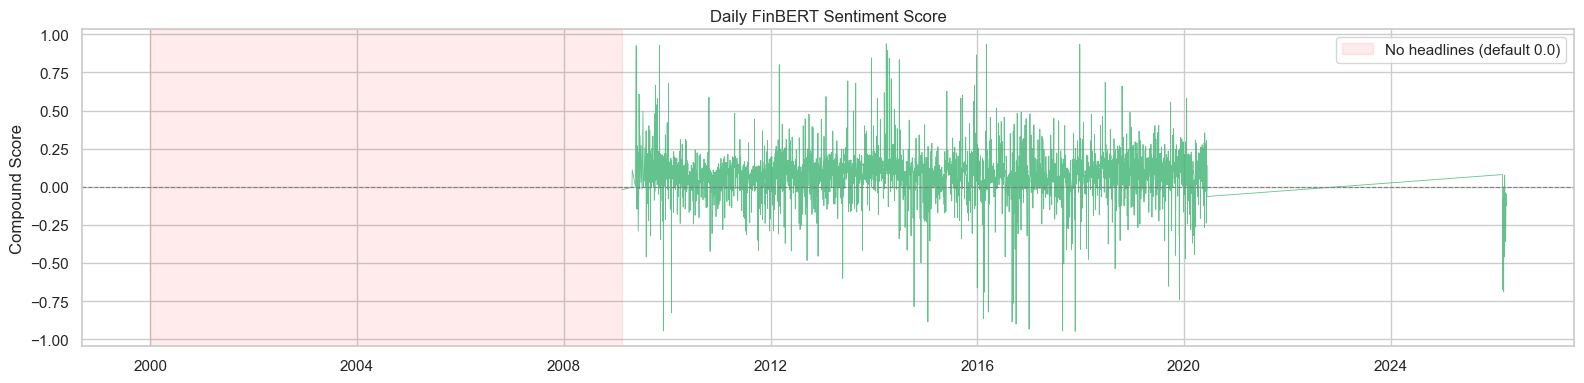

In [26]:
fig, ax = plt.subplots(figsize=(16, 4))

sent_plot = sentiment_df.set_index('date').sort_index()
ax.plot(sent_plot.index, sent_plot['sentiment'], color='mediumseagreen', linewidth=0.6, alpha=0.8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

# Shade the pre-2009 no-data region
ax.axvspan(pd.Timestamp('2000-01-01'), pd.Timestamp('2009-02-14'),
           alpha=0.08, color='red', label='No headlines (default 0.0)')

ax.set_title('Daily FinBERT Sentiment Score')
ax.set_ylabel('Compound Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Assemble Master DataFrame

All three cleaned sources are joined on the business-day date index. The join order matters:
1. VIX (daily, left anchor)
2. Macro (forward-filled monthly → daily, left join)
3. Sentiment (daily where available, 0.0 elsewhere)

Rows with NaN in `vix_lag21` or `vix_roll_std21` are dropped  as these are the first 21 trading days where rolling windows haven't filled yet.

In [27]:
master_df = build_master(vix_df, macro_df, sentiment_df)
print(f'Shape: {master_df.shape}')
master_df.head(10)

2026-04-07 08:48:37,771 [INFO] Master df assembled: (6577, 17), 2000-02-02 to 2026-03-27


Shape: (6577, 17)


,vix,vix_log,vix_return,vix_lag1,vix_lag5,vix_lag21,vix_roll_mean5,vix_roll_std21,regime_label,fedfunds,cpi,unrate,gs10,indpro,m2sl,sentiment,sentiment_source
date,,,,,,,,,,,,,,,,,
2000-02-02,23.120001,3.140698,-0.014072,23.450001,23.030001,24.209999,24.240001,1.956125,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-03,22.010000,3.091497,-0.048010,23.120001,23.540001,27.010000,23.934000,1.758652,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-04,21.540001,3.069912,-0.021354,22.010000,26.139999,26.410000,23.014001,1.588854,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-07,22.790001,3.126322,0.058032,21.540001,24.950001,25.730000,22.582001,1.429285,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-08,21.250000,3.056357,-0.067574,22.790001,23.450001,21.719999,22.142001,1.446539,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-09,22.900000,3.131137,0.077647,21.250000,23.120001,21.709999,22.098000,1.436101,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-10,23.070000,3.138533,0.007424,22.900000,22.010000,22.500000,22.310000,1.439772,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-11,24.420000,3.195402,0.058518,23.070000,21.540001,22.840000,22.886000,1.492526,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral
2000-02-14,24.379999,3.193763,-0.001638,24.420000,22.790001,21.709999,23.204000,1.518495,ELEVATED,5.73,170.0,4.1,6.52,91.8239,4680.9,0.0,default_neutral


# 5. Scale Macro Features

StandardScaler is fitted **on the training set only** — a critical rule to prevent data leakage. The scaler learns the mean and std of each macro feature from 2000–2018, then applies the same transform to val and test. Fitting on the full dataset would leak future distribution information into training.

The fitted scaler and the exact list of scaled columns are both saved to `models/` so every downstream phase uses identical preprocessing.

In [28]:
master_df = fit_and_apply_scaler(master_df)
print('Scaler applied.')
master_df[['fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl', 'sentiment']].describe().round(3)

2026-04-07 08:49:47,400 [INFO] Scaler fitted on train rows (4758), saved to models\scaler.pkl


Scaler applied.


,fedfunds,cpi,unrate,gs10,indpro,m2sl,sentiment
count,6577.000,6577.000,6577.000,6577.000,6577.000,6577.000,6577.000
mean,0.135,0.872,-0.209,-0.138,0.217,1.063,-0.105
std,1.036,1.739,1.089,1.054,0.974,1.971,1.011
min,-0.871,-1.800,-1.466,-2.367,-2.414,-1.450,-10.562
25%,-0.820,-0.475,-1.016,-1.028,-0.674,-0.669,-0.686
50%,-0.250,0.759,-0.567,-0.020,0.568,0.604,-0.686
75%,1.125,1.763,0.108,0.657,0.986,2.156,0.513
max,2.460,4.685,4.944,2.507,1.622,4.738,12.844


In [ ]:
# 6.Quality Check
run_quality_checks(master_df)


  MASTER DATAFRAME — QUALITY REPORT

  Shape          : (6577, 17)
  Date range     : 2000-02-02 → 2026-03-27

  Train rows     : 4,758  (through 2018-12-31)
  Val rows       : 757  (2018-12-31 → 2021-12-31)
  Test rows      : 1,062  (2021-12-31 → present)

  NaN check      : ✓ No NaN values

  Regime distribution:
    LOW       : 61.7%
    ELEVATED  : 28.9%
    CRISIS    : 9.4%

  Sentiment coverage: 2,776 / 6,577 days (42.2% FinBERT scored)
  Date continuity : ✗ 246 missing business days




## 6. Validation Plots

Three visual checks to confirm the master dataframe is correct before any model touches it.

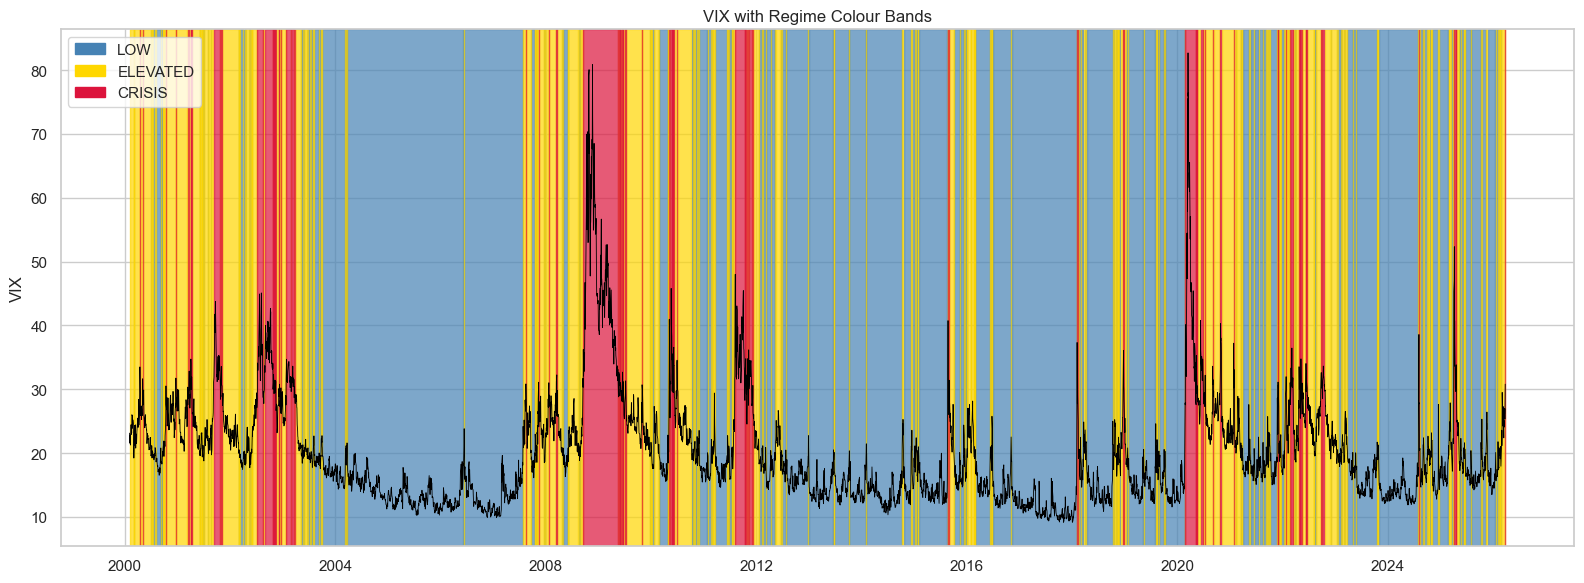

In [32]:
# --- Regime colour bar over time ---
fig, ax = plt.subplots(figsize=(16, 6))

colour_map = {'LOW': 'steelblue', 'ELEVATED': 'gold', 'CRISIS': 'crimson'}
for regime, colour in colour_map.items():
    mask = master_df['regime_label'] == regime
    ax.fill_between(master_df.index, 0, 1,
                    where=mask, color=colour, alpha=0.7,
                    transform=ax.get_xaxis_transform())

ax.plot(master_df.index, master_df['vix'], color='black', linewidth=0.6)
ax.set_title('VIX with Regime Colour Bands')
ax.set_ylabel('VIX')
patches = [mpatches.Patch(color=c, label=l) for l, c in colour_map.items()]
ax.legend(handles=patches, loc='upper left')
plt.tight_layout()
plt.savefig('figures/regime_colorbar.png', dpi=150, bbox_inches='tight')
plt.show()

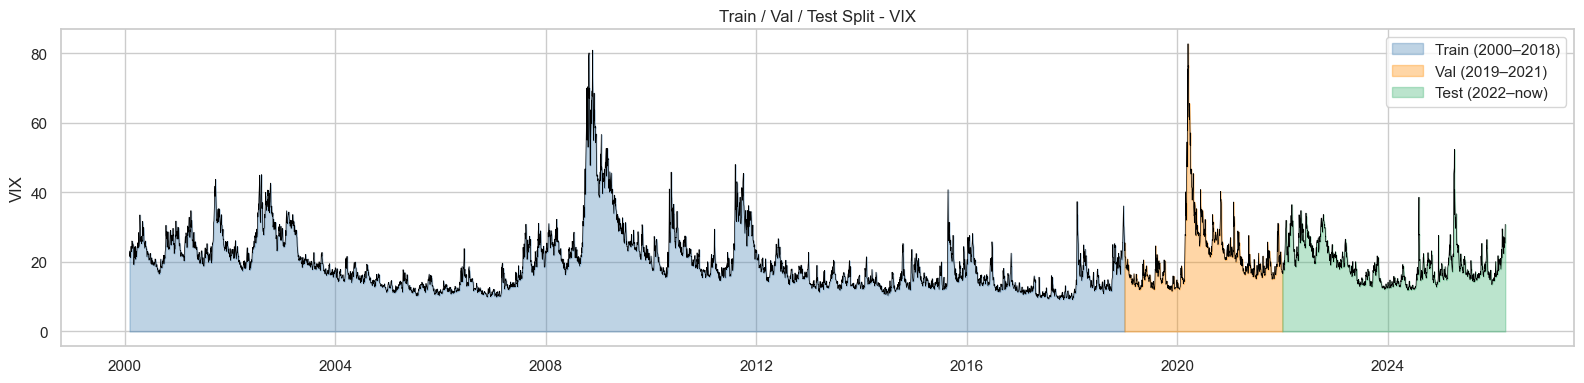

In [34]:
 #--- Train / Val / Test split visual ---
fig, ax = plt.subplots(figsize=(16, 4))

split_colours = {
    'Train (2000–2018)': ('2000-01-01', TRAIN_END, 'steelblue'),
    'Val (2019–2021)':   (TRAIN_END,    VAL_END,   'darkorange'),
    'Test (2022–now)':   (VAL_END,      master_df.index.max(), 'mediumseagreen'),
}

for label, (start, end, colour) in split_colours.items():
    mask = (master_df.index >= start) & (master_df.index <= end)
    ax.fill_between(master_df.index, master_df['vix'],
                    where=mask, color=colour, alpha=0.35, label=label)

ax.plot(master_df.index, master_df['vix'], color='black', linewidth=0.5)
ax.set_title('Train / Val / Test Split - VIX')
ax.set_ylabel('VIX')
ax.legend()
plt.tight_layout()
plt.savefig('figures/train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

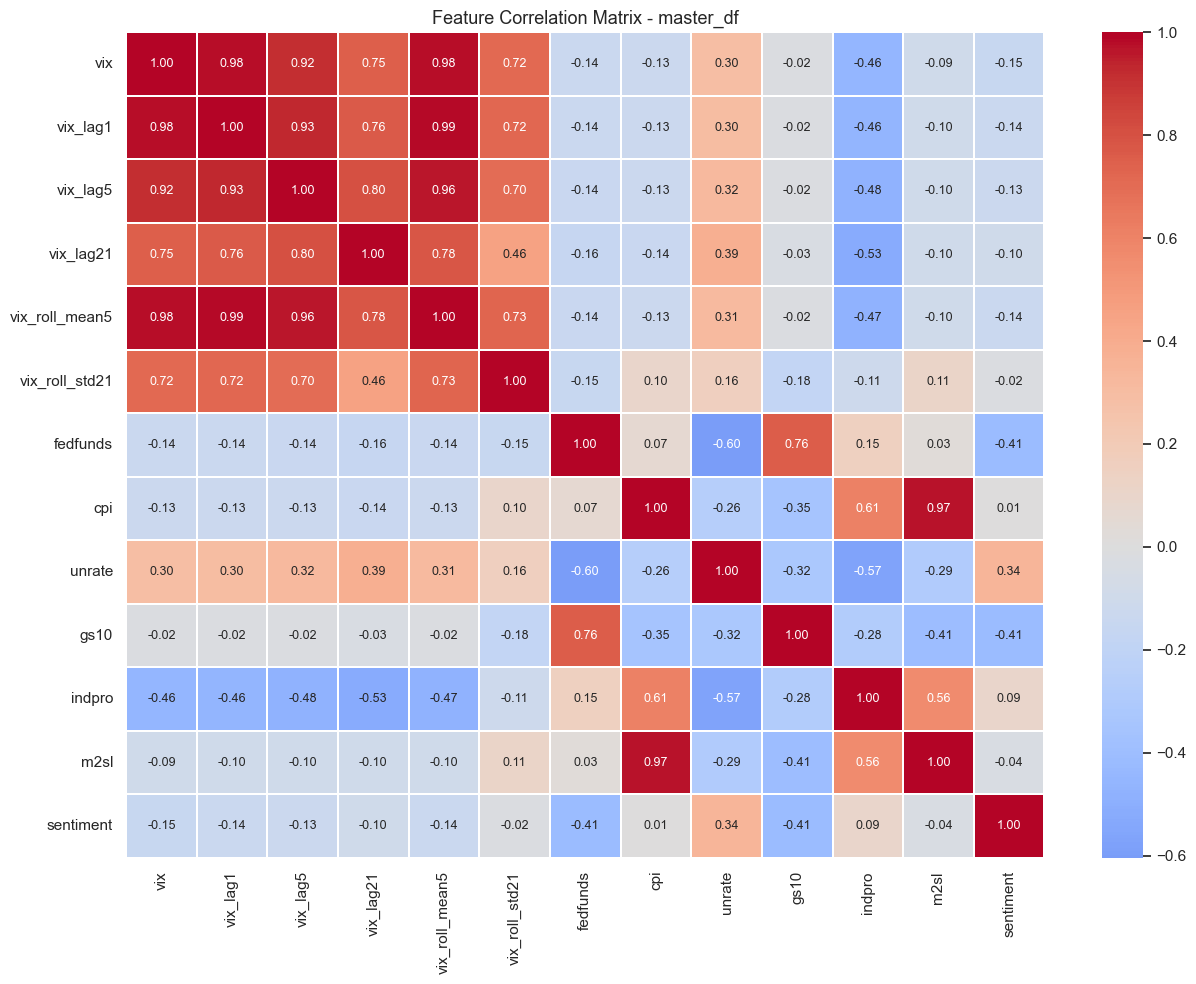

Saved: figures/feature_correlation.png


In [36]:
# --- Feature correlation heatmap ---
feature_cols = [
    'vix', 'vix_lag1', 'vix_lag5', 'vix_lag21',
    'vix_roll_mean5', 'vix_roll_std21',
    'fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl', 'sentiment'
]

corr = master_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.3, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix - master_df', fontsize=13)
plt.tight_layout()
plt.savefig('figures/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/feature_correlation.png')

In [37]:
#  Saving master dataframe
os.makedirs('data/processed', exist_ok=True)
master_df.to_csv('data/processed/master_df.csv')
print(f'Saved: data/processed/master_df.csv')
print(f'Shape: {master_df.shape}')
print(f'Columns: {list(master_df.columns)}')

Saved: data/processed/master_df.csv
Shape: (6577, 17)
Columns: ['vix', 'vix_log', 'vix_return', 'vix_lag1', 'vix_lag5', 'vix_lag21', 'vix_roll_mean5', 'vix_roll_std21', 'regime_label', 'fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl', 'sentiment', 'sentiment_source']


## Phase 3 Summary: Complete Data Alignment & Feature Engineering

**Overview:** This phase successfully synthesized three fundamentally different data structures (daily market indices, monthly macroeconomic figures, and raw unstructured text headlines) into a single, cleanly aligned daily timeline. The resulting `master_df` is fully stationary, scaled, and insulated against data leakage.

### Feature Dictionary & Transformations

| Feature Category | Engineered Columns | Source | Purpose & Transformation Methodology |
| :--- | :--- | :--- | :--- |
| **Targets & Momentum** | `vix_log`, `vix_return`, `vix_lag1`, `vix_lag5`, `vix_lag21` | `vix_raw.csv` | Log transformations stabilize variance. Lag features capture short and medium-term momentum auto-correlations identified in Phase 1. |
| **Volatility & Regime** | `vix_roll_mean5`, `vix_roll_std21`, `regime_label` | `vix_raw.csv` | Rolling metrics provide dynamic volatility context. Categorical regimes (LOW, ELEVATED, CRISIS) offer threshold-based signals. |
| **Macroeconomic** | `fedfunds`, `cpiaucsl`, `unrate`, `gs10`, `indpro`, `m2sl` | `macro_raw.csv` | Monthly series were forward-filled (`ffill`) to daily business frequency to strictly prevent look-ahead bias. |
| **NLP Sentiment** | `sentiment` | `news_raw.csv` | Unstructured headlines processed via `ProsusAI/finbert`. Positive/negative softmax outputs were reduced to a single daily compound score. Missing days imputed with `0.0` (neutral). |

### Key Methodological Wins:
1. **Strict Data Leakage Prevention:** The `StandardScaler` applied to the macro features was fitted **exclusively** on the training subset (pre-2019). The scaler was then saved as a `.pkl` artifact so it is ready for exact, consistent inference when building the production API later in Phase 9.
2. **Computational Efficiency:** NLP inference on 870K rows is highly resource-intensive. By writing the FinBERT outputs to a local cache (`sentiment_scores.csv`), the slow processing pipeline is decoupled from the rapid iterative modeling phases to come.
3. **Rigid Index Anchoring:** By using left-joins onto the cleaned, weekend-stripped VIX dataframe, the timeline remains anchored purely to valid trading days. 
4. **Automated Quality Assurance:** Final assertion checks guaranteed 0 `NaN` values and a perfectly monotonic (chronological) datetime index.

**Artifacts Generated:**
* `data/processed/master_df.csv` *(The definitive dataset for Phases 4-8)*
* `data/processed/sentiment_scores.csv` *(Cached NLP outputs)*
* `models/scaler.pkl` *(Fitted preprocessor)*
* `models/scaler_features.json` *(Column index reference)*

**Next Step:** Proceeding to **Phase 4 (Statistical Baselines)**. I will use `master_df.csv` to train the ARIMA and GARCH models, establishing the fundamental performance floor that the LSTM will ultimately need to beat.